         date     county  fips  confirmed_cases  deaths  new_confirmed_cases  \
0  2021-09-02    Alameda     1           109537    1316                655.0   
1  2021-09-02     Alpine     3               89       0                  0.0   
2  2021-09-02     Amador     5             4559      53                 33.0   
3  2021-09-02      Butte     7            16281     209                108.0   
4  2021-09-02  Calaveras     9             2948      63                 25.0   

   new_deaths  
0         2.0  
1         0.0  
2         0.0  
3         0.0  
4         0.0  
Index(['date', 'county', 'fips', 'confirmed_cases', 'deaths',
       'new_confirmed_cases', 'new_deaths'],
      dtype='str')
          county  Cluster
0        Alameda        2
1         Alpine        2
2         Amador        2
3          Butte        2
4      Calaveras        2
5         Colusa        2
6   Contra Costa        2
7      Del Norte        2
8      El Dorado        2
9         Fresno        2
10         

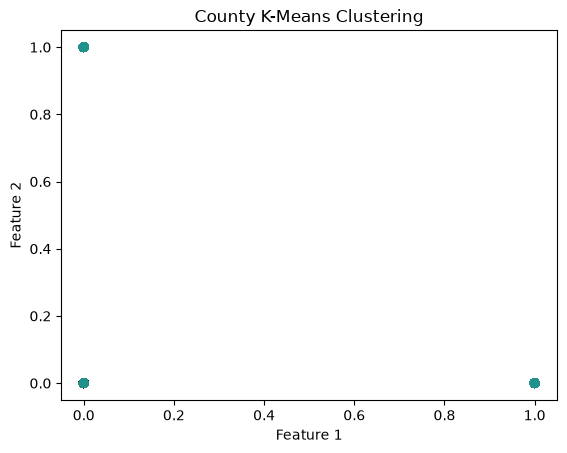

In [1]:
# Install/import libraries
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("latimes-county-totals.csv")
print(df.head())
print(df.columns)

# Select text column (change 'county' if needed)
text_col = "county"

# Clean text
df["clean_text"] = df[text_col].astype(str).str.lower()
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"[^a-z\s]", "", x)
)

# NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["clean_text"])

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Show results
print(df[[text_col, "Cluster"]].head(20))

# Cluster counts
print("\nCluster Counts:")
print(df["Cluster"].value_counts())

# Save results
df.to_csv("county_kmeans_results.csv", index=False)

# Plot
plt.scatter(X.toarray()[:, 0], X.toarray()[:, 1], c=df["Cluster"])
plt.title("County K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()